In [1]:
pip install torch scikit-learn scipy matplotlib numpy

In [22]:
from google.colab import files
uploaded = files.upload()

Saving SP500_data_fixed.xlsx to SP500_data_fixed.xlsx


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# ============================================================
# TSGBench CONFIG  --  edit for your data
# ============================================================
# Two assets: META & TROW (subset of the MCT-TEAM-GAN universe).
TICKERS = ['META', 'TROW']

REAL_FILE   = 'SP500_data_fixed.xlsx'      # real prices; has a 'Date' column + ticker columns
SYNTH_FILE  = 'synthetic_META_TROW.xlsx'   # synthetic prices in a sheet named 'Prices'
SYNTH_SHEET = 'Prices'                      # sheet holding the 2 synthetic price columns

WINDOW_LENGTH = 120        # TSGBench window length (matches the 120-day generator horizon)
WINDOW_STRIDE = 1          # step between consecutive windows
DATE_START    = '2013-01-01'   # real-data date filter; set DATE_START=None to use all rows
DATE_END      = '2025-01-01'

# Runtime caps so the 2-feature evaluation stays tractable in Colab:
MAX_EVAL_WINDOWS = 1000    # #windows fed to every metric (sub-sampled, consistent)
DTW_MAX_SAMPLES  = 200     # extra cap for the (slow, O(L^2)) DTW metric


In [24]:
def _select_ticker_columns(df, tickers, source_name):
    """Return df restricted to `tickers` (canonical order/names); robust to case
    and to an extra Date/index column. Raises a clear error if a ticker is absent."""
    cols_upper = {str(c).upper(): c for c in df.columns}
    selected, missing = [], []
    for t in tickers:
        if t.upper() in cols_upper:
            selected.append(cols_upper[t.upper()])
        else:
            missing.append(t)
    if missing:
        avail = list(df.columns)
        raise ValueError(
            f"{source_name}: missing ticker columns {missing}. "
            f"Available ({len(avail)}): {avail[:30]}{' ...' if len(avail) > 30 else ''}"
        )
    out = df[selected].copy()
    out.columns = list(tickers)      # enforce identical order & names on both sides
    return out


def load_and_preprocess_data(real_file_path, synthetic_file_path, tickers=None,
                             synth_sheet=None, date_start=None, date_end=None):
    """Load real + synthetic PRICES for `tickers` and return aligned log-return arrays.

    Returns:
        real_log_returns:  (T, n_features) ndarray of log returns
        synth_log_returns: (T, n_features) ndarray of log returns
        tickers:           the feature order (list)
    """
    if tickers     is None: tickers     = TICKERS
    if synth_sheet is None: synth_sheet = SYNTH_SHEET
    if date_start  is None: date_start  = DATE_START
    if date_end    is None: date_end    = DATE_END

    # ---- REAL (Excel, has a Date column) ----
    real_df = pd.read_excel(real_file_path)
    print(f"[real]  raw shape={real_df.shape}")
    if 'Date' in real_df.columns and date_start is not None:
        real_df['Date'] = pd.to_datetime(real_df['Date'])
        mask = (real_df['Date'] >= pd.Timestamp(date_start)) & (real_df['Date'] < pd.Timestamp(date_end))
        real_df = real_df[mask]
        print(f"[real]  after {date_start}..{date_end}: {real_df.shape}")

    real_prices = _select_ticker_columns(real_df, tickers, 'real').dropna()
    real_log_returns = np.log(real_prices.pct_change().dropna() + 1.0)

    # ---- SYNTHETIC (Excel, 'Prices' sheet) ----
    xl = pd.ExcelFile(synthetic_file_path)
    print(f"[synth] sheets={xl.sheet_names}")
    sheet = synth_sheet if synth_sheet in xl.sheet_names else xl.sheet_names[-1]
    synth_df = pd.read_excel(synthetic_file_path, sheet_name=sheet)
    print(f"[synth] sheet='{sheet}' shape={synth_df.shape}")

    synth_prices = _select_ticker_columns(synth_df, tickers, 'synthetic').dropna()
    synth_log_returns = np.log(synth_prices.pct_change().dropna() + 1.0)

    # ---- align length + identical feature order ----
    n = min(len(real_log_returns), len(synth_log_returns))
    real_log_returns  = real_log_returns.iloc[:n]
    synth_log_returns = synth_log_returns.iloc[:n]
    print(f"[aligned] real={real_log_returns.shape}  synth={synth_log_returns.shape}")
    print(f"[features] {list(tickers)}")

    return real_log_returns.values, synth_log_returns.values, list(tickers)


In [25]:
# Smoke-test the data loading
try:
    real_data, synthetic_data, feature_names = load_and_preprocess_data(REAL_FILE, SYNTH_FILE, TICKERS)
    print("\nLoaded OK")
    print(f"  real  log-returns: {real_data.shape}")
    print(f"  synth log-returns: {synthetic_data.shape}")
    print(f"  features: {feature_names}")
    print(f"  real  range  [{real_data.min():.6f}, {real_data.max():.6f}]")
    print(f"  synth range  [{synthetic_data.min():.6f}, {synthetic_data.max():.6f}]")
except Exception as e:
    import traceback; traceback.print_exc()


[real]  raw shape=(6289, 502)
[real]  after 2013-01-01..2025-01-01: (3020, 502)
[synth] sheets=['Prices']
[synth] sheet='Prices' shape=(2001, 2)
[aligned] real=(2000, 2)  synth=(2000, 2)
[features] ['META', 'TROW']

Loaded OK
  real  log-returns: (2000, 2)
  synth log-returns: (2000, 2)
  features: ['META', 'TROW']
  real  range  [-0.210239, 0.259371]
  synth range  [-0.199790, 0.200210]


In [26]:
def normalize_data(data):
    """
    Normalize data to [0, 1] range as required by TSGBench
    """
    if len(data) == 0:
        raise ValueError("Empty data array")

    min_vals = np.min(data, axis=(0, 1), keepdims=True)
    max_vals = np.max(data, axis=(0, 1), keepdims=True)

    # Avoid division by zero
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1

    normalized_data = (data - min_vals) / range_vals

    # Ensure values are in [0, 1] range
    normalized_data = np.clip(normalized_data, 0, 1)

    return normalized_data, min_vals, max_vals

In [27]:
def create_time_series_windows(data, window_length=24, stride=1):
    """
    Convert time series data into overlapping windows for TSGBench format

    Args:
        data: numpy array of shape (time_steps, n_features)
        window_length: length of each window
        stride: step size between windows

    Returns:
        windowed_data: numpy array of shape (n_windows, window_length, n_features)
    """
    if len(data) < window_length:
        raise ValueError(f"Data length ({len(data)}) is less than window length ({window_length})")

    n_windows = (len(data) - window_length) // stride + 1
    windows = []

    for i in range(0, n_windows * stride, stride):
        if i + window_length <= len(data):
            windows.append(data[i:i + window_length])

    return np.array(windows)


In [28]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 2)  # Binary classification

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # Use last time step
        return out

def discriminative_score(real_data, synthetic_data, num_runs=5):
    """
    Compute Discriminative Score using LSTM classifier
    Args:
        real_data: numpy array of shape (n_samples, seq_len, n_features)
        synthetic_data: numpy array of shape (n_samples, seq_len, n_features)
        num_runs: number of runs for averaging
    Returns:
        ds_score: mean classification error
        ds_std: standard deviation across runs
    """
    scores = []

    for run in range(num_runs):
        # Prepare data
        X = np.concatenate([real_data, synthetic_data], axis=0)
        y = np.concatenate([np.ones(len(real_data)), np.zeros(len(synthetic_data))])

        # Convert to tensors
        X_tensor = torch.FloatTensor(X)
        y_tensor = torch.LongTensor(y)

        # Split train/test
        split_idx = int(0.8 * len(X))
        indices = np.random.permutation(len(X))
        train_idx, test_idx = indices[:split_idx], indices[split_idx:]

        train_dataset = TensorDataset(X_tensor[train_idx], y_tensor[train_idx])
        test_dataset = TensorDataset(X_tensor[test_idx], y_tensor[test_idx])

        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=32)

        # Initialize model
        model = LSTMClassifier(X.shape[2])
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters())

        # Train
        model.train()
        for epoch in range(50):
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

        # Test
        model.eval()
        predictions = []
        true_labels = []

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                _, predicted = torch.max(outputs.data, 1)
                predictions.extend(predicted.numpy())
                true_labels.extend(batch_y.numpy())

        accuracy = accuracy_score(true_labels, predictions)
        error_rate = 1 - accuracy
        scores.append(error_rate)

    return np.mean(scores), np.std(scores)


In [29]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=1):
        super(LSTMPredictor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # Use last time step
        # Handle dimension mismatch
        if out.dim() == 1 and self.fc.out_features > 1:
            out = out.unsqueeze(0)
        return out


def predictive_score(real_data, synthetic_data, prediction_type='next_step', num_runs=5):
    """
    Compute Predictive Score
    """
    scores = []

    for run in range(num_runs):
        if prediction_type == 'next_step':
            # Prepare data for next-step prediction
            X_train = synthetic_data[:, :-1, :]  # All but last timestep
            y_train = synthetic_data[:, -1, :]   # Last timestep

            X_test = real_data[:, :-1, :]
            y_test = real_data[:, -1, :]

        else:  # entire_sequence
            # Use first half to predict second half
            seq_len = synthetic_data.shape[1]
            mid_point = seq_len // 2

            X_train = synthetic_data[:, :mid_point, :]
            y_train = synthetic_data[:, mid_point:, :].reshape(len(synthetic_data), -1)

            X_test = real_data[:, :mid_point, :]
            y_test = real_data[:, mid_point:, :].reshape(len(real_data), -1)

        # Convert to tensors
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train)
        X_test_tensor = torch.FloatTensor(X_test)
        y_test_tensor = torch.FloatTensor(y_test)

        # Initialize model
        output_size = y_train.shape[1] if len(y_train.shape) > 1 else 1
        model = LSTMPredictor(X_train.shape[2], output_size=output_size)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters())

        # Train on synthetic data
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

        model.train()
        for epoch in range(50):
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

        # Test on real data
        model.eval()
        with torch.no_grad():
            predictions = model(X_test_tensor)
            mae = torch.mean(torch.abs(predictions - y_test_tensor)).item()
            scores.append(mae)

    return np.mean(scores), np.std(scores)

In [30]:
from scipy.linalg import sqrtm

def contextual_fid(real_data, synthetic_data, embedding_model=None):
    """
    Compute Contextual-FID using time series embeddings
    Args:
        real_data: numpy array of shape (n_samples, seq_len, n_features)
        synthetic_data: numpy array of shape (n_samples, seq_len, n_features)
        embedding_model: pre-trained embedding model (e.g., ts2vec)
    """
    if embedding_model is None:
        # Simple embedding using mean and std across time dimension
        real_embeddings = np.concatenate([
            np.mean(real_data, axis=1),
            np.std(real_data, axis=1)
        ], axis=1)

        synthetic_embeddings = np.concatenate([
            np.mean(synthetic_data, axis=1),
            np.std(synthetic_data, axis=1)
        ], axis=1)
    else:
        # Use pre-trained embedding model
        real_embeddings = embedding_model.encode(real_data)
        synthetic_embeddings = embedding_model.encode(synthetic_data)

    # Calculate FID
    mu_real = np.mean(real_embeddings, axis=0)
    mu_synthetic = np.mean(synthetic_embeddings, axis=0)

    sigma_real = np.cov(real_embeddings, rowvar=False)
    sigma_synthetic = np.cov(synthetic_embeddings, rowvar=False)

    # Calculate FID score
    diff = mu_real - mu_synthetic
    covmean = sqrtm(sigma_real.dot(sigma_synthetic))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma_real + sigma_synthetic - 2 * covmean)
    return fid


In [31]:
def marginal_distribution_difference(real_data, synthetic_data, n_bins=50):
    """
    Compute Marginal Distribution Difference
    Args:
        real_data: numpy array of shape (n_samples, seq_len, n_features)
        synthetic_data: numpy array of shape (n_samples, seq_len, n_features)
        n_bins: number of histogram bins
    """
    mdd_scores = []

    for feature_idx in range(real_data.shape[2]):
        for time_idx in range(real_data.shape[1]):
            real_values = real_data[:, time_idx, feature_idx]
            synthetic_values = synthetic_data[:, time_idx, feature_idx]

            # Create histogram bins based on real data
            bin_edges = np.histogram_bin_edges(real_values, bins=n_bins)

            # Calculate histograms
            real_hist, _ = np.histogram(real_values, bins=bin_edges, density=True)
            synthetic_hist, _ = np.histogram(synthetic_values, bins=bin_edges, density=True)

            # Calculate absolute difference
            mdd = np.mean(np.abs(real_hist - synthetic_hist))
            mdd_scores.append(mdd)

    return np.mean(mdd_scores)


In [32]:
def autocorrelation_difference(real_data, synthetic_data, max_lag=20):
    """
    Compute AutoCorrelation Difference
    Args:
        real_data: numpy array of shape (n_samples, seq_len, n_features)
        synthetic_data: numpy array of shape (n_samples, seq_len, n_features)
        max_lag: maximum lag for autocorrelation
    """
    def compute_autocorr(data, max_lag):
        autocorrs = []
        for i in range(data.shape[0]):  # For each sample
            for j in range(data.shape[2]):  # For each feature
                series = data[i, :, j]
                autocorr = np.correlate(series, series, mode='full')
                autocorr = autocorr[len(autocorr)//2:]
                autocorr = autocorr[:max_lag+1] / autocorr[0]  # Normalize
                autocorrs.append(autocorr)
        return np.array(autocorrs)

    real_autocorr = compute_autocorr(real_data, max_lag)
    synthetic_autocorr = compute_autocorr(synthetic_data, max_lag)

    # Calculate mean autocorrelation across all samples and features
    real_mean_autocorr = np.mean(real_autocorr, axis=0)
    synthetic_mean_autocorr = np.mean(synthetic_autocorr, axis=0)

    acd = np.mean(np.abs(real_mean_autocorr - synthetic_mean_autocorr))
    return acd


In [33]:
from scipy.stats import skew

def skewness_difference(real_data, synthetic_data):
    """
    Compute Skewness Difference
    Args:
        real_data: numpy array of shape (n_samples, seq_len, n_features)
        synthetic_data: numpy array of shape (n_samples, seq_len, n_features)
    """
    # Flatten data for each feature
    real_flat = real_data.reshape(-1, real_data.shape[2])
    synthetic_flat = synthetic_data.reshape(-1, synthetic_data.shape[2])

    skewness_diffs = []
    for feature_idx in range(real_data.shape[2]):
        real_skew = skew(real_flat[:, feature_idx])
        synthetic_skew = skew(synthetic_flat[:, feature_idx])
        skewness_diffs.append(abs(real_skew - synthetic_skew))

    return np.mean(skewness_diffs)


In [34]:
from scipy.stats import kurtosis

def kurtosis_difference(real_data, synthetic_data):
    """
    Compute Kurtosis Difference
    Args:
        real_data: numpy array of shape (n_samples, seq_len, n_features)
        synthetic_data: numpy array of shape (n_samples, seq_len, n_features)
    """
    # Flatten data for each feature
    real_flat = real_data.reshape(-1, real_data.shape[2])
    synthetic_flat = synthetic_data.reshape(-1, synthetic_data.shape[2])

    kurtosis_diffs = []
    for feature_idx in range(real_data.shape[2]):
        real_kurt = kurtosis(real_flat[:, feature_idx])
        synthetic_kurt = kurtosis(synthetic_flat[:, feature_idx])
        kurtosis_diffs.append(abs(real_kurt - synthetic_kurt))

    return np.mean(kurtosis_diffs)


In [35]:
def euclidean_distance(real_data, synthetic_data):
    """
    Compute Euclidean Distance between real and synthetic data
    Args:
        real_data: numpy array of shape (n_samples, seq_len, n_features)
        synthetic_data: numpy array of shape (n_samples, seq_len, n_features)
    """
    # Ensure same number of samples
    min_samples = min(len(real_data), len(synthetic_data))
    real_subset = real_data[:min_samples]
    synthetic_subset = synthetic_data[:min_samples]

    # Calculate Euclidean distance for each pair
    distances = []
    for i in range(min_samples):
        dist = np.sqrt(np.sum((real_subset[i] - synthetic_subset[i]) ** 2))
        distances.append(dist)

    return np.mean(distances)


In [36]:
def dtw_distance(x, y):
    """
    Compute DTW distance between two time series
    """
    n, m = len(x), len(y)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(x[i-1] - y[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j],      # insertion
                                         dtw_matrix[i, j-1],      # deletion
                                         dtw_matrix[i-1, j-1])    # match

    return dtw_matrix[n, m]

def dynamic_time_warping(real_data, synthetic_data):
    """
    Compute mean DTW distance between real and synthetic data
    Args:
        real_data: numpy array of shape (n_samples, seq_len, n_features)
        synthetic_data: numpy array of shape (n_samples, seq_len, n_features)
    """
    min_samples = min(len(real_data), len(synthetic_data))
    dtw_distances = []

    for i in range(min_samples):
        for j in range(real_data.shape[2]):  # For each feature
            real_series = real_data[i, :, j]
            synthetic_series = synthetic_data[i, :, j]
            dtw_dist = dtw_distance(real_series, synthetic_series)
            dtw_distances.append(dtw_dist)

    return np.mean(dtw_distances)


In [37]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def tsne_visualization(real_data, synthetic_data, save_path=None):
    """
    Create t-SNE visualization of real vs synthetic data
    Args:
        real_data: numpy array of shape (n_samples, seq_len, n_features)
        synthetic_data: numpy array of shape (n_samples, seq_len, n_features)
        save_path: path to save the plot
    """
    # Flatten data for t-SNE
    real_flat = real_data.reshape(len(real_data), -1)
    synthetic_flat = synthetic_data.reshape(len(synthetic_data), -1)

    # Combine data
    combined_data = np.vstack([real_flat, synthetic_flat])
    labels = np.hstack([np.ones(len(real_data)), np.zeros(len(synthetic_data))])

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    embedded = tsne.fit_transform(combined_data)

    # Plot
    plt.figure(figsize=(10, 8))
    real_mask = labels == 1
    synthetic_mask = labels == 0

    plt.scatter(embedded[real_mask, 0], embedded[real_mask, 1],
                c='blue', label='Real', alpha=0.6)
    plt.scatter(embedded[synthetic_mask, 0], embedded[synthetic_mask, 1],
                c='orange', label='Synthetic', alpha=0.6)

    plt.legend()
    plt.title('t-SNE Visualization: Real vs Synthetic Data')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')

    if save_path:
        plt.savefig(save_path)
    plt.show()


In [38]:
def distribution_plot(real_data, synthetic_data, feature_idx=0, save_path=None):
    """
    Create distribution comparison plot
    Args:
        real_data: numpy array of shape (n_samples, seq_len, n_features)
        synthetic_data: numpy array of shape (n_samples, seq_len, n_features)
        feature_idx: which feature to plot
        save_path: path to save the plot
    """
    # Flatten the selected feature
    real_values = real_data[:, :, feature_idx].flatten()
    synthetic_values = synthetic_data[:, :, feature_idx].flatten()

    plt.figure(figsize=(12, 6))

    # Plot histograms
    plt.hist(real_values, bins=50, alpha=0.7, label='Real', color='blue', density=True)
    plt.hist(synthetic_values, bins=50, alpha=0.7, label='Synthetic', color='orange', density=True)

    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.title(f'Distribution Comparison - Feature {feature_idx}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path)
    plt.show()


In [39]:
def run_complete_tsgbench_evaluation(real_file_path, synthetic_file_path,
                                     tickers=None, window_length=None, stride=None,
                                     max_windows=None, dtw_max_samples=None,
                                     num_runs=3, seed=42):
    """Full TSGBench evaluation on YOUR data (joint over all features).

    Returns: (results dict, real_normalized, synth_normalized)
    """
    if tickers         is None: tickers         = TICKERS
    if window_length   is None: window_length   = WINDOW_LENGTH
    if stride          is None: stride          = WINDOW_STRIDE
    if max_windows     is None: max_windows     = MAX_EVAL_WINDOWS
    if dtw_max_samples is None: dtw_max_samples = DTW_MAX_SAMPLES
    rng = np.random.default_rng(seed)

    print("Loading and preprocessing data...")
    real_returns, synth_returns, tickers = load_and_preprocess_data(
        real_file_path, synthetic_file_path, tickers)

    # ---- window ----
    real_w  = create_time_series_windows(real_returns,  window_length, stride)
    synth_w = create_time_series_windows(synth_returns, window_length, stride)
    print(f"Windowed: real={real_w.shape}  synth={synth_w.shape}")

    # ---- cap #windows (consistent) so 10-feature metrics stay tractable ----
    def _cap(a, k):
        if len(a) > k:
            idx = np.sort(rng.choice(len(a), k, replace=False))
            return a[idx]
        return a
    real_w  = _cap(real_w,  max_windows)
    synth_w = _cap(synth_w, max_windows)

    # ---- normalize to [0,1] with a SHARED scaler fit on REAL (TSGBench convention) ----
    # Fitting separate min/max per side injects an affine offset that artificially
    # separates real vs synth (inflates DS / t-SNE / MDD / C-FID / ED / DTW).
    real_normalized, mn, mx = normalize_data(real_w)
    synth_normalized = np.clip((synth_w - mn) / (mx - mn), 0, 1)
    print(f"Normalised:  real={real_normalized.shape}  synth={synth_normalized.shape}")
    print(f"Evaluating jointly over {real_normalized.shape[2]} features: {tickers}\n")

    results = {}

    # ---------- Model-based ----------
    print("Computing Model-based Measures...")
    try:
        m, s = discriminative_score(real_normalized, synth_normalized, num_runs=num_runs)
        results['DS'] = {'mean': m, 'std': s}; print(f"  Discriminative Score: {m:.4f} +/- {s:.4f}")
    except Exception as e:
        print(f"  DS error: {e}"); results['DS'] = {'mean': np.nan, 'std': np.nan}
    try:
        m, s = predictive_score(real_normalized, synth_normalized, num_runs=num_runs)
        results['PS'] = {'mean': m, 'std': s}; print(f"  Predictive Score:     {m:.4f} +/- {s:.4f}")
    except Exception as e:
        print(f"  PS error: {e}"); results['PS'] = {'mean': np.nan, 'std': np.nan}
    try:
        results['C-FID'] = contextual_fid(real_normalized, synth_normalized)
        print(f"  Contextual-FID:       {results['C-FID']:.4f}")
    except Exception as e:
        print(f"  C-FID error: {e}"); results['C-FID'] = np.nan

    # ---------- Feature-based ----------
    print("Computing Feature-based Measures...")
    for key, fn, label in [
        ('MDD', marginal_distribution_difference, 'Marginal Distribution Diff'),
        ('ACD', autocorrelation_difference,       'AutoCorrelation Difference'),
        ('SD',  skewness_difference,              'Skewness Difference'),
        ('KD',  kurtosis_difference,              'Kurtosis Difference'),
    ]:
        try:
            results[key] = fn(real_normalized, synth_normalized)
            print(f"  {label}: {results[key]:.4f}")
        except Exception as e:
            print(f"  {key} error: {e}"); results[key] = np.nan

    # ---------- Distance-based ----------
    print("Computing Distance-based Measures...")
    try:
        results['ED'] = euclidean_distance(real_normalized, synth_normalized)
        print(f"  Euclidean Distance:   {results['ED']:.4f}")
    except Exception as e:
        print(f"  ED error: {e}"); results['ED'] = np.nan
    try:
        k = min(dtw_max_samples, len(real_normalized), len(synth_normalized))
        results['DTW'] = dynamic_time_warping(real_normalized[:k], synth_normalized[:k])
        print(f"  Dynamic Time Warping: {results['DTW']:.4f}  (on {k} windows)")
    except Exception as e:
        print(f"  DTW error: {e}"); results['DTW'] = np.nan

    # ---------- Visualizations ----------
    print("Creating Visualizations...")
    try:
        create_comprehensive_plots(real_normalized, synth_normalized, real_returns, synth_returns, tickers)
    except Exception as e:
        print(f"  Plot error: {e}")

    return results, real_normalized, synth_normalized


def create_comprehensive_plots(real_normalized, synth_normalized, real_raw, synth_raw, tickers):
    """t-SNE + mean-autocorrelation overview, then a per-asset return-distribution grid."""
    n_feat = real_normalized.shape[2]

    # ---- Figure 1: t-SNE + mean autocorrelation ----
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    try:
        from sklearn.manifold import TSNE
        rf = real_normalized.reshape(len(real_normalized), -1)
        sf = synth_normalized.reshape(len(synth_normalized), -1)
        k = min(1000, len(rf), len(sf))
        ri = np.random.choice(len(rf), k, replace=False)
        si = np.random.choice(len(sf), k, replace=False)
        comb = np.vstack([rf[ri], sf[si]])
        emb = TSNE(n_components=2, random_state=42,
                   perplexity=min(30, max(5, k // 4))).fit_transform(comb)
        ax[0].scatter(emb[:k, 0], emb[:k, 1], c='royalblue',  s=12, alpha=0.5, label='Real')
        ax[0].scatter(emb[k:, 0], emb[k:, 1], c='darkorange', s=12, alpha=0.5, label='Synthetic')
        ax[0].set_title('t-SNE: Real vs Synthetic'); ax[0].legend()
    except Exception as e:
        ax[0].text(0.5, 0.5, f't-SNE error:\n{e}', ha='center', va='center'); ax[0].set_title('t-SNE (error)')

    try:
        max_lag = 20
        def _mean_ac(data):
            acs = []
            for j in range(n_feat):
                s = data[:, :, j].mean(axis=0)
                ac = np.correlate(s, s, mode='full'); ac = ac[len(ac) // 2:][:max_lag + 1]
                acs.append(ac / ac[0])
            return np.mean(acs, axis=0)
        ax[1].plot(_mean_ac(real_normalized),  'b-',  lw=2, label='Real')
        ax[1].plot(_mean_ac(synth_normalized), 'r--', lw=2, label='Synthetic')
        ax[1].set_title('Mean Autocorrelation (avg over assets)')
        ax[1].set_xlabel('Lag'); ax[1].set_ylabel('Autocorrelation'); ax[1].legend(); ax[1].grid(alpha=0.3)
    except Exception as e:
        ax[1].text(0.5, 0.5, f'ACF error:\n{e}', ha='center', va='center'); ax[1].set_title('ACF (error)')
    plt.tight_layout(); plt.savefig('tsgbench_overview.png', dpi=150, bbox_inches='tight'); plt.show()

    # ---- Figure 2: per-asset return distribution (real vs synth) ----
    ncol = min(5, n_feat); nrow = int(np.ceil(n_feat / ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow))
    axs = np.atleast_1d(axs).flatten()
    for j in range(n_feat):
        rv = real_normalized[:, :, j].flatten()
        sv = synth_normalized[:, :, j].flatten()
        axs[j].hist(rv, bins=50, alpha=0.6, density=True, color='royalblue',  label='Real')
        axs[j].hist(sv, bins=50, alpha=0.6, density=True, color='darkorange', label='Synthetic')
        axs[j].set_title(tickers[j], fontsize=10); axs[j].legend(fontsize=7); axs[j].grid(alpha=0.3)
    for kk in range(n_feat, len(axs)):
        axs[kk].axis('off')
    fig.suptitle('Per-asset return distributions (normalised windows)', fontsize=14, y=1.02)
    plt.tight_layout(); plt.savefig('tsgbench_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


def print_results_summary(results):
    """Formatted summary of all TSGBench metrics."""
    def _f(x): return f"{x:.4f}" if isinstance(x, (int, float)) and not (isinstance(x, float) and np.isnan(x)) else "nan"
    print("\n" + "=" * 60)
    print("TSGBench EVALUATION RESULTS SUMMARY  (joint over all assets)")
    print("=" * 60)
    print("\nMODEL-BASED MEASURES:")
    print(f"  Discriminative Score (DS):     {_f(results['DS']['mean'])} +/- {_f(results['DS']['std'])}")
    print(f"  Predictive Score (PS):         {_f(results['PS']['mean'])} +/- {_f(results['PS']['std'])}")
    print(f"  Contextual-FID (C-FID):        {_f(results['C-FID'])}")
    print("\nFEATURE-BASED MEASURES:")
    print(f"  Marginal Distribution Diff:    {_f(results['MDD'])}")
    print(f"  AutoCorrelation Difference:    {_f(results['ACD'])}")
    print(f"  Skewness Difference:           {_f(results['SD'])}")
    print(f"  Kurtosis Difference:           {_f(results['KD'])}")
    print("\nDISTANCE-BASED MEASURES:")
    print(f"  Euclidean Distance:            {_f(results['ED'])}")
    print(f"  Dynamic Time Warping:          {_f(results['DTW'])}")
    print("\nINTERPRETATION:")
    print("  - Lower is better for every metric except DS/PS, where ~0.5 means")
    print("    the classifier cannot tell real from synthetic (i.e. good).")
    print("=" * 60)


In [40]:
def evaluate_tsg_methods(real_data, synthetic_data, num_runs=5):
    """
    Complete evaluation suite for TSG methods
    Args:
        real_data: numpy array of shape (n_samples, seq_len, n_features)
        synthetic_data: numpy array of shape (n_samples, seq_len, n_features)
        num_runs: number of runs for stochastic measures
    Returns:
        results: dictionary containing all evaluation metrics
    """
    results = {}

    print("Computing Model-based Measures...")
    # Model-based measures
    ds_mean, ds_std = discriminative_score(real_data, synthetic_data, num_runs)
    ps_mean, ps_std = predictive_score(real_data, synthetic_data, num_runs=num_runs)
    c_fid = contextual_fid(real_data, synthetic_data)

    results['DS'] = {'mean': ds_mean, 'std': ds_std}
    results['PS'] = {'mean': ps_mean, 'std': ps_std}
    results['C-FID'] = c_fid

    print("Computing Feature-based Measures...")
    # Feature-based measures
    results['MDD'] = marginal_distribution_difference(real_data, synthetic_data)
    results['ACD'] = autocorrelation_difference(real_data, synthetic_data)
    results['SD'] = skewness_difference(real_data, synthetic_data)
    results['KD'] = kurtosis_difference(real_data, synthetic_data)

    print("Computing Distance-based Measures...")
    # Distance-based measures
    results['ED'] = euclidean_distance(real_data, synthetic_data)
    results['DTW'] = dynamic_time_warping(real_data, synthetic_data)

    print("Creating Visualizations...")
    # Visualizations
    tsne_visualization(real_data, synthetic_data)
    distribution_plot(real_data, synthetic_data)

    return results

Loading and preprocessing data...
[real]  raw shape=(6289, 502)
[real]  after 2013-01-01..2025-01-01: (3020, 502)
[synth] sheets=['Prices']
[synth] sheet='Prices' shape=(2001, 2)
[aligned] real=(2000, 2)  synth=(2000, 2)
[features] ['META', 'TROW']
Windowed: real=(1881, 120, 2)  synth=(1881, 120, 2)
Normalised:  real=(1000, 120, 2)  synth=(1000, 120, 2)
Evaluating jointly over 2 features: ['META', 'TROW']

Computing Model-based Measures...
  Discriminative Score: 0.5058 +/- 0.0042
  Predictive Score:     0.0335 +/- 0.0005
  Contextual-FID:       0.0004
Computing Feature-based Measures...
  Marginal Distribution Diff: 0.2764
  AutoCorrelation Difference: 0.0050
  Skewness Difference: 0.7080
  Kurtosis Difference: 3.0838
Computing Distance-based Measures...
  Euclidean Distance:   1.1947
  Dynamic Time Warping: 3.9512  (on 200 windows)
Creating Visualizations...


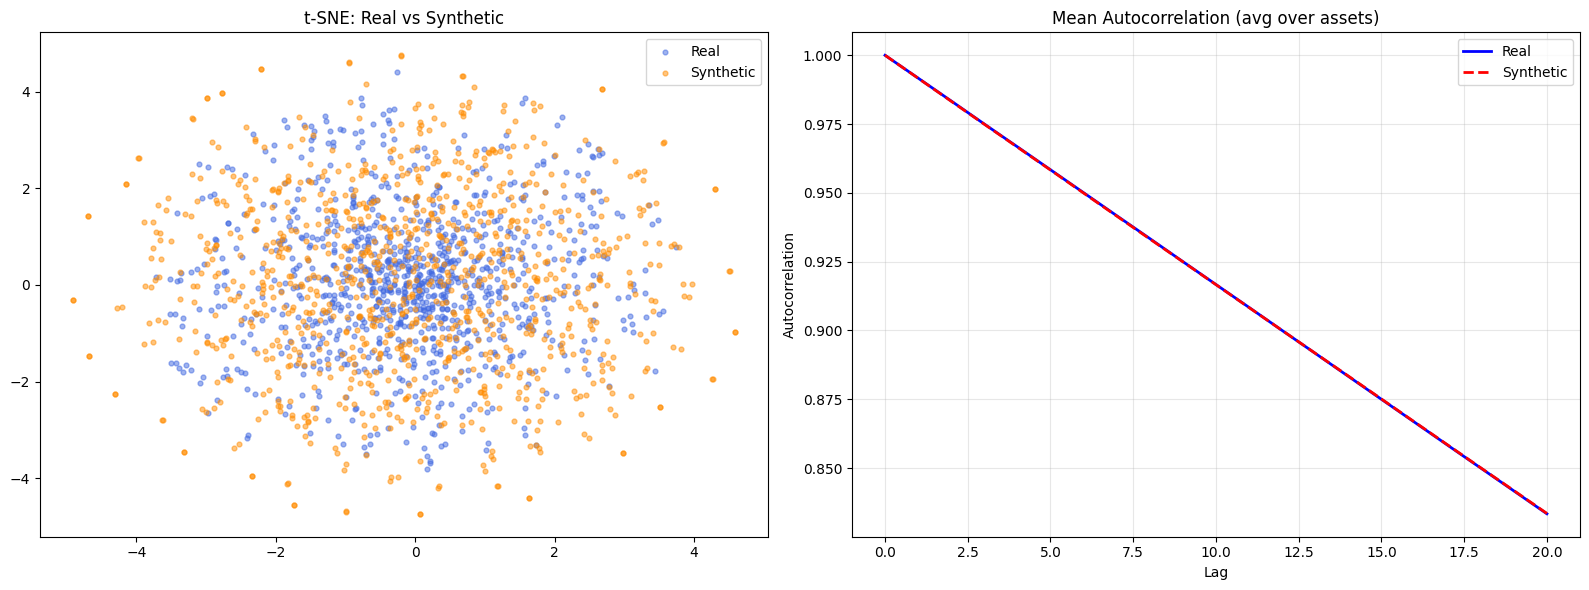

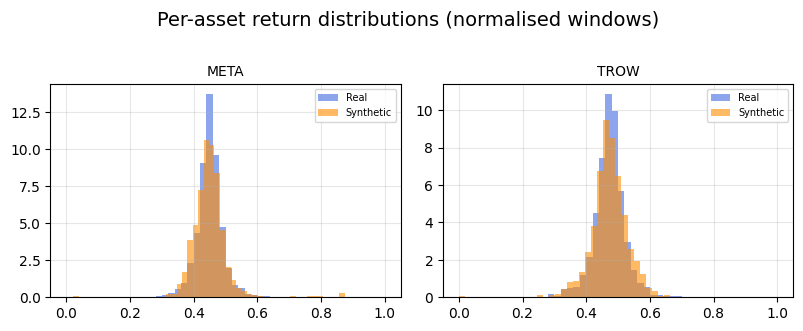


TSGBench EVALUATION RESULTS SUMMARY  (joint over all assets)

MODEL-BASED MEASURES:
  Discriminative Score (DS):     0.5058 +/- 0.0042
  Predictive Score (PS):         0.0335 +/- 0.0005
  Contextual-FID (C-FID):        0.0004

FEATURE-BASED MEASURES:
  Marginal Distribution Diff:    0.2764
  AutoCorrelation Difference:    0.0050
  Skewness Difference:           0.7080
  Kurtosis Difference:           3.0838

DISTANCE-BASED MEASURES:
  Euclidean Distance:            1.1947
  Dynamic Time Warping:          3.9512

INTERPRETATION:
  - Lower is better for every metric except DS/PS, where ~0.5 means
    the classifier cannot tell real from synthetic (i.e. good).


In [41]:
results, real_norm, synth_norm = run_complete_tsgbench_evaluation(
    REAL_FILE, SYNTH_FILE,
    tickers=TICKERS,
    window_length=WINDOW_LENGTH,
)

print_results_summary(results)
